# Model 2: Random Forest

In [ ]:
#imports

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, confusion_matrix
)

In [ ]:
# Reading in data where the genres have been categorized into three classes
df = pd.read_csv('final_df.csv')

In [ ]:
# Drop non-feature columns
drop_cols = ['filename', 'length', 'label', 'final_group']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols]
y = df['final_group']

print(f'Features: {X.shape[1]}')
print(f'Classes:  {sorted(y.unique())}')

Features: 57
Classes:  ['Acoustic', 'Electric', 'Rhythmic']


In [ ]:
# Stratified train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# Scale features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Train: {X_train_scaled.shape}  |  Test: {X_test_scaled.shape}')
print(f'\nTrain class distribution:')
print(y_train.value_counts())

Train: (800, 57)  |  Test: (200, 57)

Train class distribution:
final_group
Rhythmic    320
Electric    240
Acoustic    240
Name: count, dtype: int64


In [ ]:
rf_baseline = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_baseline.fit(X_train_scaled, y_train)

y_pred_base = rf_baseline.predict(X_test_scaled)

acc_base   = accuracy_score(y_test, y_pred_base)
f1_w_base  = f1_score(y_test, y_pred_base, average='weighted')
f1_m_base  = f1_score(y_test, y_pred_base, average='macro')

print('=== Baseline Random Forest ===')
print(f'Accuracy  : {acc_base:.4f}')
print(f'Weighted F1: {f1_w_base:.4f}')
print(f'Macro F1   : {f1_m_base:.4f}')
print()
print(classification_report(y_test, y_pred_base))

=== Baseline Random Forest ===
Accuracy  : 0.8000
Weighted F1: 0.8016
Macro F1   : 0.8049

              precision    recall  f1-score   support

    Acoustic       0.91      0.80      0.85        60
    Electric       0.82      0.77      0.79        60
    Rhythmic       0.73      0.82      0.77        80

    accuracy                           0.80       200
   macro avg       0.82      0.80      0.80       200
weighted avg       0.81      0.80      0.80       200



In [ ]:
# 5-fold cross-validation on the full dataset for a more robust estimate
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(
    RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    X, y, cv=cv, scoring='accuracy'
)
print(f'5-fold CV Accuracy: {cv_scores.mean():.4f} ± {cv_scores.std():.4f}')
print(f'Per-fold: {np.round(cv_scores, 4)}')

5-fold CV Accuracy: 0.7940 ± 0.0326
Per-fold: [0.79 0.77 0.82 0.75 0.84]


In [8]:
param_grid = {
    'n_estimators'     : [100, 200, 300],
    'max_depth'        : [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf' : [1, 2, 4],
    'max_features'     : ['sqrt', 'log2']
}

rf = RandomForestClassifier(random_state=42, n_jobs=-1)

grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    refit=True
)

grid_search.fit(X_train_scaled, y_train)

print(f'Best params : {grid_search.best_params_}')
print(f'Best CV acc : {grid_search.best_score_:.4f}')

Fitting 5 folds for each of 216 candidates, totalling 1080 fits
Best params : {'max_depth': 20, 'max_features': 'sqrt', 'min_samples_leaf': 1, 'min_samples_split': 5, 'n_estimators': 200}
Best CV acc : 0.7887


In [9]:
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test_scaled)

acc_best  = accuracy_score(y_test, y_pred_best)
f1_w_best = f1_score(y_test, y_pred_best, average='weighted')
f1_m_best = f1_score(y_test, y_pred_best, average='macro')

print('=== Tuned Random Forest ===')
print(f'Accuracy  : {acc_best:.4f}')
print(f'Weighted F1: {f1_w_best:.4f}')
print(f'Macro F1   : {f1_m_best:.4f}')
print()
print(classification_report(y_test, y_pred_best))

=== Tuned Random Forest ===
Accuracy  : 0.8200
Weighted F1: 0.8213
Macro F1   : 0.8242

              precision    recall  f1-score   support

    Acoustic       0.93      0.83      0.88        60
    Electric       0.84      0.77      0.80        60
    Rhythmic       0.75      0.85      0.80        80

    accuracy                           0.82       200
   macro avg       0.84      0.82      0.82       200
weighted avg       0.83      0.82      0.82       200



In [15]:
# Compare baseline vs tuned
comparison = pd.DataFrame({
    'Model'      : ['Naive Baseline (rolloff_mean)', 'Random Forest (baseline)', 'Random Forest (tuned)'],
    'Accuracy'   : [55.20, acc_base, acc_best],   # fill in naive baseline accuracy manually if known
    'Weighted F1': [0.53, f1_w_base, f1_w_best],
    'Macro F1'   : [0.55, f1_m_base, f1_m_best]
})
print(comparison.to_string(index=False))

                        Model  Accuracy  Weighted F1  Macro F1
Naive Baseline (rolloff_mean)     55.20     0.530000  0.550000
     Random Forest (baseline)      0.80     0.801570  0.804864
        Random Forest (tuned)      0.82     0.821287  0.824172


In [11]:
importances = best_rf.feature_importances_
feat_imp_df = pd.DataFrame({
    'feature'   : feature_cols,
    'importance': importances
}).sort_values('importance', ascending=False)

print('Top 20 features by importance:')
print(feat_imp_df.head(20).to_string(index=False))

Top 20 features by importance:
                feature  importance
       chroma_stft_mean    0.073086
             mfcc1_mean    0.047658
           rolloff_mean    0.044942
           perceptr_var    0.042114
zero_crossing_rate_mean    0.040118
 spectral_centroid_mean    0.039426
spectral_bandwidth_mean    0.033105
  spectral_centroid_var    0.029273
              mfcc5_var    0.028337
            mfcc20_mean    0.025154
             mfcc4_mean    0.020867
             mfcc2_mean    0.020596
            rolloff_var    0.019862
              mfcc4_var    0.019527
              mfcc7_var    0.018118
               rms_mean    0.017992
              mfcc6_var    0.017822
             mfcc20_var    0.017747
        chroma_stft_var    0.017341
 zero_crossing_rate_var    0.016568


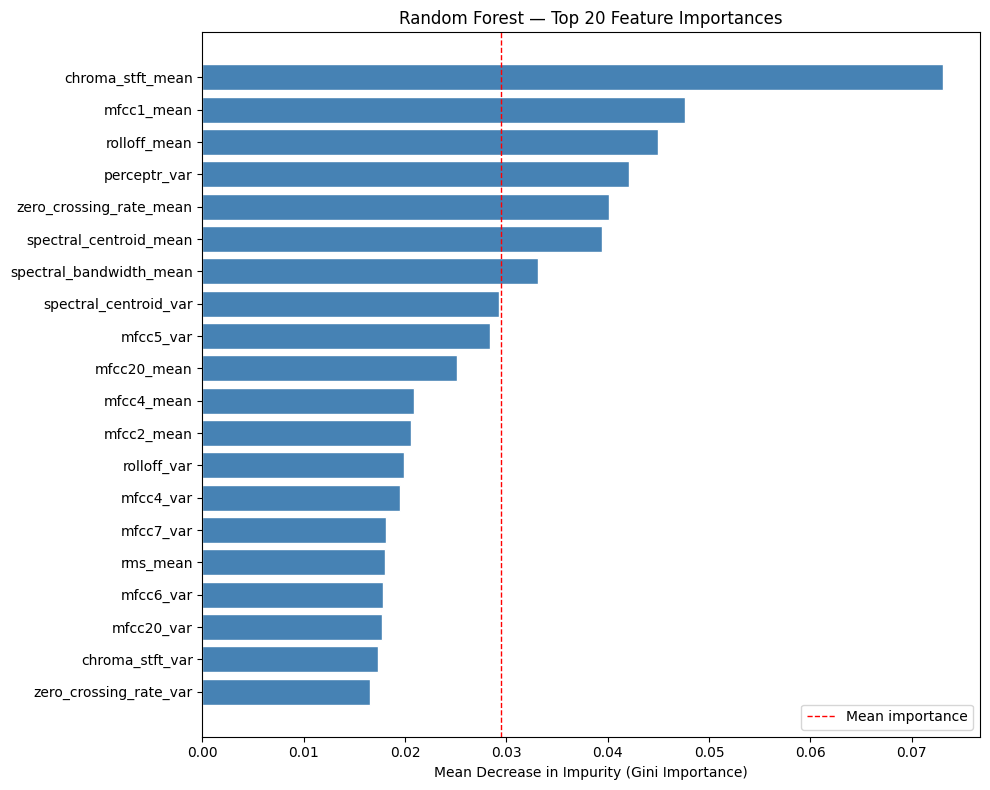

In [12]:
fig, ax = plt.subplots(figsize=(10, 8))

top_n = 20
top_feats = feat_imp_df.head(top_n)

bars = ax.barh(top_feats['feature'][::-1], top_feats['importance'][::-1],
               color='steelblue', edgecolor='white')

ax.set_xlabel('Mean Decrease in Impurity (Gini Importance)')
ax.set_title(f'Random Forest — Top {top_n} Feature Importances')
ax.axvline(x=top_feats['importance'].mean(), color='red', linestyle='--',
           linewidth=1, label='Mean importance')
ax.legend()
plt.tight_layout()
plt.show()

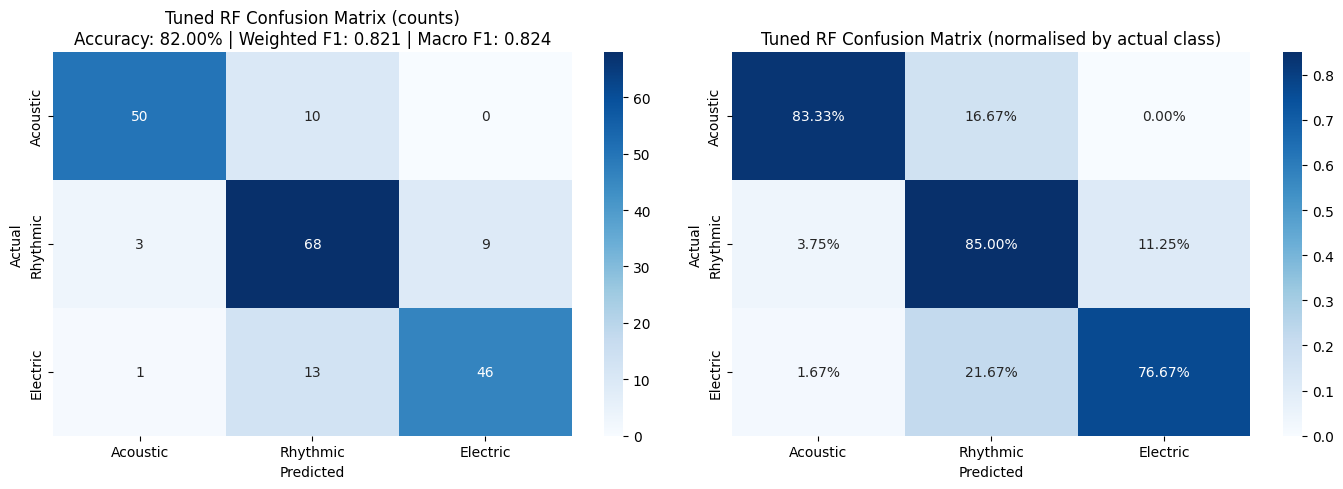

In [13]:
labels = ['Acoustic', 'Rhythmic', 'Electric']
cm = confusion_matrix(y_test, y_pred_best, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[0])
axes[0].set_title(f'Tuned RF Confusion Matrix (counts)\nAccuracy: {acc_best:.2%} | Weighted F1: {f1_w_best:.3f} | Macro F1: {f1_m_best:.3f}')
axes[0].set_ylabel('Actual')
axes[0].set_xlabel('Predicted')

# Normalised (recall per class)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues',
            xticklabels=labels, yticklabels=labels, ax=axes[1])
axes[1].set_title('Tuned RF Confusion Matrix (normalised by actual class)')
axes[1].set_ylabel('Actual')
axes[1].set_xlabel('Predicted')

plt.tight_layout()
plt.show()